# NMDS, Heat Maps, and Bar plots of normalized abundance

This jupyter notebook will walk you through the data processing and visualization of proteome data measured from Ruegeria pomeroyi Strain DSS-3 under different media conditions, as conducted in the Master Thesis / Publication by Fadime R. Stemmer (2025): "The Exo-proteomic Framework for Nitrogen Acquisition from Proteinaceous Organic Matter in the Model Marine Heterotroph Ruegeria Pomeroyi DSS-3".

You should have opened this jupyter notebook after cloning the respective GitHub repository 'Rpom_Exoproteome' onto your computer. The file structure of this repo will be used in this code, so for this code to work, it is important that files are not moved or renamed. If you decide to move/rename the files, please adjust the jupyter notebook filepaths accordingly.

## Step 1: Import libraries
First we import all libraries for data import, manipulation, statistical analysis, and visualization.

In [3]:
import os
import glob
import pandas as pd
import numpy as np
import numpy.ma as ma 
import matplotlib as mpl
from sklearn.manifold import MDS
from scipy.spatial.distance import pdist, squareform, braycurtis
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Ellipse
from skbio.stats.distance import permanova, DistanceMatrix
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import ListedColormap
from matplotlib import cm
from bokeh.io import show, output_file
from bokeh.models import ColumnDataSource
from bokeh.plotting import figure
import itertools

mpl.rcParams['font.family'] = 'Arial'

## Step 2: Import Files
Make sure that you ran the scripts in the folder 'fragpipe/' prior to this such that annotated proteome files (i.e. files with the extension '_annotated.txt' are present in the 'data/' folder.

In [2]:
'''
Function to load the data from _annotated.txt files as dictionary values and assign to key (= growth medium). 
If successful the function will prompt: "PROTEOME loaded into script!"

USAGE: load_data(folder='FOLDERNAME_CONTAINING_annotated_TXTFILES')
'''
proteome_dic = {}

def load_data(folder=''):
    proteome_dic = {}
    
    for file in glob.glob(os.path.join(folder, '*_annotated.txt')):
        parts = os.path.basename(file).replace('.txt', '').strip().split('_')
        
        # Default: just join everything from 2 to 5 like before
        medium_phase = '_'.join(parts[2:3])
        
        data = pd.read_csv(file, delimiter='\t')
        proteome_dic[medium_phase] = data
        print(f"{medium_phase} loaded into script!")
    
    return proteome_dic

In [3]:
proteome_dic=load_data('../data/proteomics/raw/')

ProMM-N+CSec loaded into script!
ProMM loaded into script!
ProMM-N+C loaded into script!
ProMMSec loaded into script!
ProMM+Cas loaded into script!


## Step 3: NMDS
Multidimensional scaling - or MDS - is a technique used for analyzing similarity or dissimilarity data. It attempts to model similarity or dissimilarity data as distances in a geometric space. The data can be ratings of similarity between objects, interaction frequencies of molecules, or trade indices between countries.

There exists two types of MDS algorithm: metric and non metric. In scikit-learn, the class MDS implements both. In Metric MDS, the input similarity matrix arises from a metric (and thus respects the triangular inequality), the distances between output two points are then set to be as close as possible to the similarity or dissimilarity data. In the non-metric version, the algorithms will try to preserve the order of the distances, and hence seek for a monotonic relationship between the distances in the embedded space and the similarities/dissimilarities.

Here we use Bray-Curtis Distance since we are dealing with spectral data (not counts).

This description was adapted from: https://scikit-learn.org/stable/modules/manifold.html#multidimensional-scaling

### Data pre-processing for NMDS
First we will need to modify our data for plotting. The following functions are used to filter proteins based on their presence in or absence from all replicates, and merges all samples into one dataframe to be used in downstream analyses. 

In [4]:
'''
The function filter_valid_proteins() is used to filter the results from proteomics such that proteins appearing in all or none of the 
triplicates are retained whereas proteins only present in one or two of the three samples are deemed unsignificant and removed from the 
dataset. This function is needed for the bar plots. 

USAGE: filter_valid_proteins(data_dic)

After the filtering step, we want to merge all individual data to one dataframe based on Accession number and Annotation. We use the 
function 'merge_data_dic()' for that.

USAGE: merge_data_dic(data_dic, trip_cols=('1', '2', '3'))

Once the dataframe is merged we modify it to be able to conduct NMDS analysis. The function data_mod() can be used to fulfil this task.
This function will extract the suffixes which correspond to the sample names from the merged dataframe. It will then create column names
using the motif 'TriplicateNumber_suffix' similar to what was saved in the merged dataframe and saves this data as 'labels' variable. 
Then we replace remaining NaN's with 0, assuming that they are true missing values. Since all samples with 1 or 2 NaN's were removed 
earlier, only triplicate NaN's are left, justifying this assumption. Finally we transpose the data to make all proteins appear as columns
and rows be the respective values


    * data_dic = dictionary containing keys = growth condition, and df = associated mass spec data in triplicates (1, 2, 3), annotations,
                 and accession numbers
    * trip_cols = triplicate columns. Should be 1, 2, 3 in each dictionary key - df pair. 

'''

def filter_valid_proteins(data_dic):
    for key, df in data_dic.items():
        triplicates = df[['1', '2', '3']] # extract the triplicate columns from the dictionary items
        # use mask to remove non-significant proteins based on absence/presence in replicates
        mask = triplicates.notna().all(axis=1) | triplicates.isna().all(axis=1)
        data_dic[key] = df[mask]
    return data_dic

proteome_dic=filter_valid_proteins(proteome_dic)
    
def merge_data_dic(data_dic, trip_cols=('1', '2', '3')):
    merged = None

    for key, df in data_dic.items():
        df = df.copy()
        # Rename only the triplicate columns that exist in this df
        rename_dict = {c: f"{c}_{key}" for c in trip_cols}
        df = df.rename(columns=rename_dict)

        if merged is None:
            merged = df
        else:
            merged = pd.merge(
                 merged,
                df,
                on=['Accession Number', 'Annotation'],
                how='outer'
            )
    return merged


merged = merge_data_dic(proteome_dic)

def data_mod(df, chosen_suffixes=None):
    # Extract all suffixes that appear in df
    all_suffixes = sorted({ col.split('_')[1] for col in df.columns if '_' in col })

    # If user provided a subset, filter to it
    if chosen_suffixes is not None:
        suffixes = [s for s in all_suffixes if s in chosen_suffixes]
    else:
        suffixes = all_suffixes

    trip_cols = []
    labels = []

    for suffix in suffixes:
        cols = [f"{i}_{suffix}" for i in ['1', '2', '3']]
        trip_cols.extend(cols)
        labels.extend([f"{suffix}_{i}" for i in ['1', '2', '3']])

    # Replace NaN with 0, assuming when there is 3 NaN's its truly missing values. 
    data = df[trip_cols].fillna(0)

    # Transpose
    data_T = data.T
    data_T.columns = [f"Prot_{i}" for i in range(data_T.shape[1])]
    data_T.index = labels

    return data_T, labels
    
data_T, labels = data_mod(merged)

     Accession Number                                         Annotation  \
0             SPO0001  tRNA uridine 5-carboxymethylaminomethyl modifi...   
1             SPO0002  Ribosomal RNA small subunit methyltransferase ...   
2             SPO0003               Chromosome partitioning protein ParA   
3             SPO0004               Chromosome partitioning protein parB   
4             SPO0005                   DUF454 domain-containing protein   
...               ...                                                ...   
3880         SPOA0445                   Ferric uptake regulation protein   
3881         SPOA0446             Transcriptional regulator, LysR family   
3882         SPOA0449           Phytanoyl-CoA dioxygenase family protein   
3883         SPOA0451             Transcriptional regulator, MarR family   
3884         SPOA0452             Transcriptional regulator, MarR family   

      1_ProMM-N+CSec  2_ProMM-N+CSec  3_ProMM-N+CSec    1_ProMM    2_ProMM  \
0        

### NMDS Plots

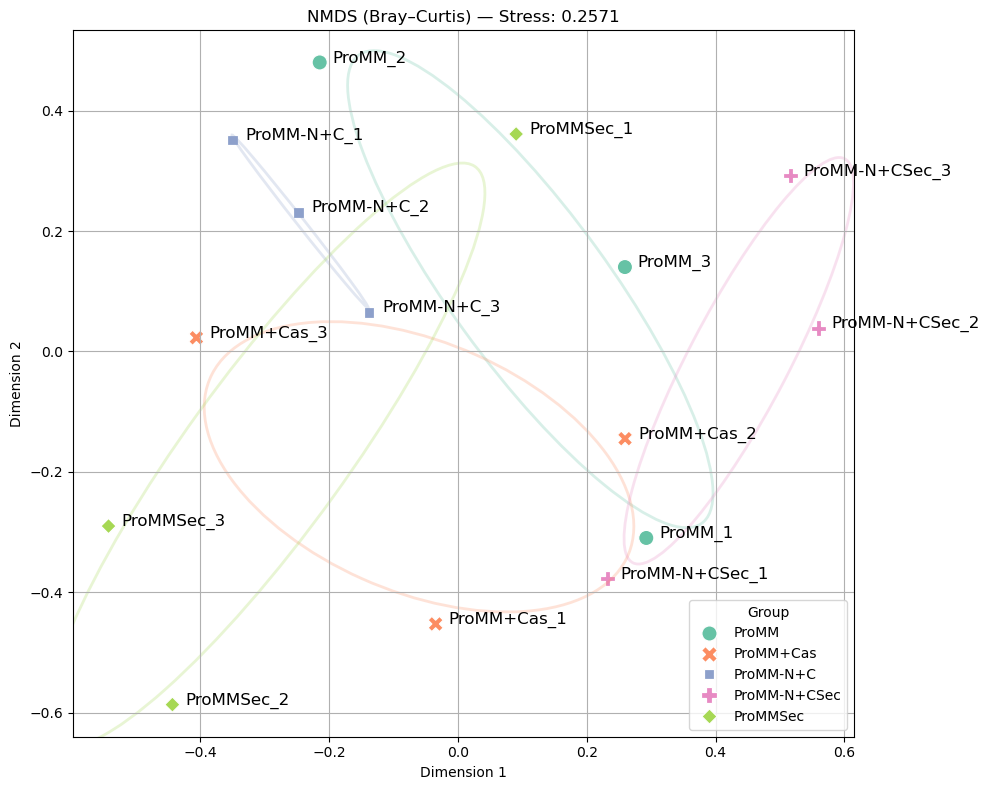


PERMANOVA Result:
method name                PERMANOVA
test statistic name         pseudo-F
sample size                       15
number of groups                   5
test statistic            187.045349
p-value                        0.001
number of permutations           999
Name: PERMANOVA results, dtype: object

NMDS Stress: 0.2571


In [13]:
def NMDS(data_T, labels):
    distance_matrix = squareform(pdist(data_T, metric='braycurtis'))

    # NMDS 
    nmds = MDS(
        n_components=2,
        dissimilarity='precomputed',
        metric=False,
        random_state=42
    )
    nmds_coords = nmds.fit_transform(distance_matrix)
    stress = nmds.stress_

    #PLOT NMDS
    df_plot = pd.DataFrame(nmds_coords, columns=['Dim1', 'Dim2'])
    df_plot['Sample'] = labels
    df_plot['Group'] = [lab.split('_')[0] for lab in labels]   # suffix grouping
    plt.figure(figsize=(10, 8))
    palette = sns.color_palette('Set2', len(df_plot['Group'].unique()))

    sns.scatterplot(
        data=df_plot,
        x='Dim1',
        y='Dim2',
        hue='Group',
        style='Group',
        s=120,
        palette=palette
    )

    # Add Ellipses
    def draw_ellipse(data, ax, edgecolor='black', alpha=0.25):
        if data.shape[0] < 2:
            return
        cov = np.cov(data.T)
        vals, vecs = np.linalg.eigh(cov)
        order = vals.argsort()[::-1]
        vals = vals[order]
        vecs = vecs[:, order]
        theta = np.degrees(np.arctan2(*vecs[:, 0][::-1]))
        width, height = 2 * np.sqrt(vals)  # 1 SD
        mean = data.mean(axis=0)
        ellipse = Ellipse(
            xy=mean,
            width=width,
            height=height,
            angle=theta,
            edgecolor=edgecolor,
            facecolor='none',
            lw=2,
            alpha=alpha
        )
        ax.add_patch(ellipse)

    ax = plt.gca()
    for i, group in enumerate(df_plot['Group'].unique()):
        group_data = df_plot[df_plot['Group'] == group][['Dim1', 'Dim2']].values
        draw_ellipse(group_data, ax, edgecolor=palette[i])

    # Add Labels
    for i in range(len(df_plot)):
        plt.text(df_plot.Dim1[i] + 0.02, df_plot.Dim2[i], df_plot.Sample[i], fontsize=12)

    plt.title(f"NMDS (Bray–Curtis) — Stress: {stress:.4f}")
    plt.xlabel("Dimension 1")
    plt.ylabel("Dimension 2")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f'../figures/proteomics/NMDS/NMDS_{stress}.pdf', format='pdf')
    plt.show()

    # PERMANOVA
    grouping = df_plot['Group'].tolist()
    dm = DistanceMatrix(distance_matrix, ids=labels)
    permanova_result = permanova(dm, grouping, permutations=999)

    print("\nPERMANOVA Result:")
    print(permanova_result)
    print(f"\nNMDS Stress: {stress:.4f}")

    return df_plot, stress, permanova_result
    
df_plot, stress, permanova_result = NMDS(data_T, labels)

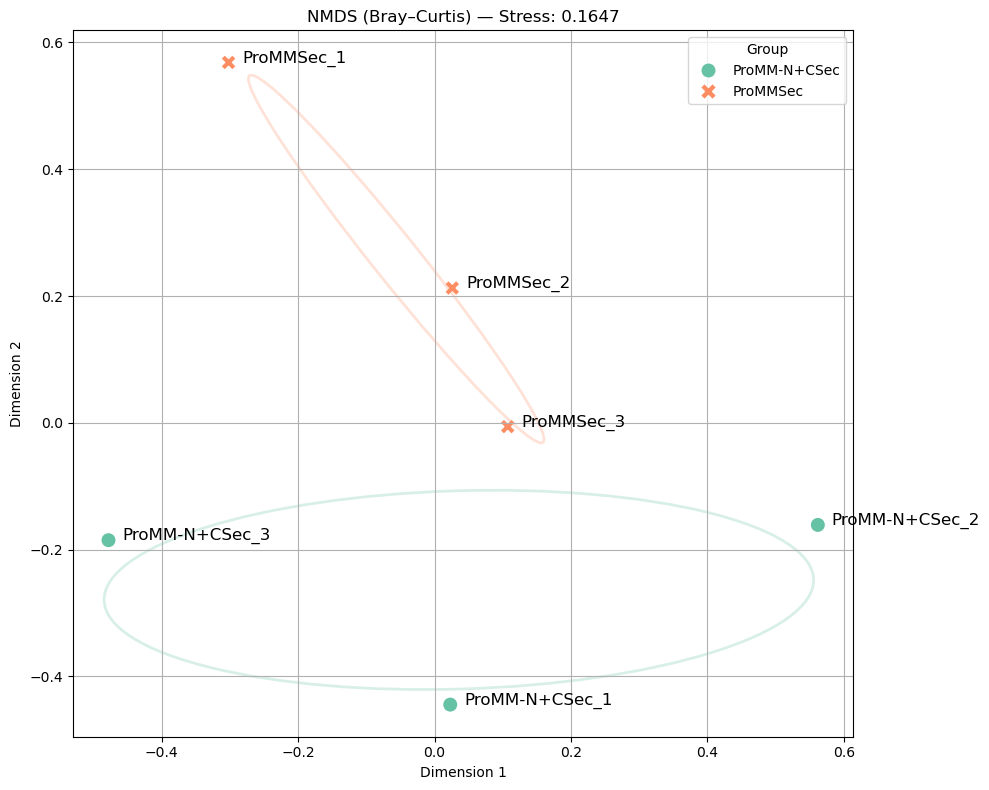


PERMANOVA Result:
method name                PERMANOVA
test statistic name         pseudo-F
sample size                        6
number of groups                   2
test statistic            115.140702
p-value                        0.088
number of permutations           999
Name: PERMANOVA results, dtype: object

NMDS Stress: 0.1647


(       Dim1      Dim2          Sample         Group
 0  0.023057 -0.444549  ProMM-N+CSec_1  ProMM-N+CSec
 1  0.562034 -0.161050  ProMM-N+CSec_2  ProMM-N+CSec
 2 -0.478056 -0.185170  ProMM-N+CSec_3  ProMM-N+CSec
 3 -0.301991  0.568499      ProMMSec_1      ProMMSec
 4  0.026060  0.212682      ProMMSec_2      ProMMSec
 5  0.107320 -0.006014      ProMMSec_3      ProMMSec,
 np.float64(0.1647160941542587),
 method name                PERMANOVA
 test statistic name         pseudo-F
 sample size                        6
 number of groups                   2
 test statistic            115.140702
 p-value                        0.088
 number of permutations           999
 Name: PERMANOVA results, dtype: object)

In [14]:
chosen = ["ProMMSec", "ProMM-N+CSec"]
data_T, labels = data_mod(merged, chosen_suffixes=chosen)
NMDS(data_T, labels)

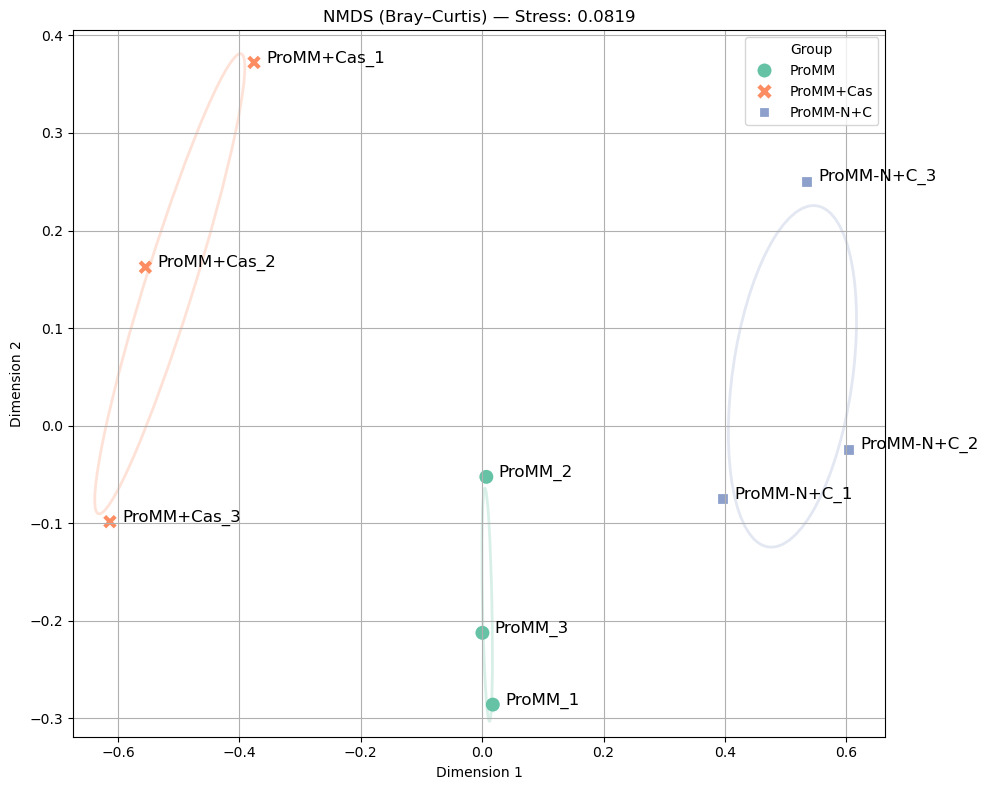


PERMANOVA Result:
method name               PERMANOVA
test statistic name        pseudo-F
sample size                       9
number of groups                  3
test statistic             21.62707
p-value                       0.005
number of permutations          999
Name: PERMANOVA results, dtype: object

NMDS Stress: 0.0819


(       Dim1      Dim2       Sample      Group
 0  0.017425 -0.285799      ProMM_1      ProMM
 1  0.006814 -0.052377      ProMM_2      ProMM
 2  0.000317 -0.212240      ProMM_3      ProMM
 3 -0.375995  0.372285  ProMM+Cas_1  ProMM+Cas
 4 -0.554909  0.162459  ProMM+Cas_2  ProMM+Cas
 5 -0.613320 -0.098340  ProMM+Cas_3  ProMM+Cas
 6  0.395895 -0.074734  ProMM-N+C_1  ProMM-N+C
 7  0.603200 -0.024028  ProMM-N+C_2  ProMM-N+C
 8  0.534192  0.250518  ProMM-N+C_3  ProMM-N+C,
 np.float64(0.08186268959320493),
 method name               PERMANOVA
 test statistic name        pseudo-F
 sample size                       9
 number of groups                  3
 test statistic             21.62707
 p-value                       0.005
 number of permutations          999
 Name: PERMANOVA results, dtype: object)

In [15]:
chosen = ["ProMM", "ProMM-N+C", "ProMM+Cas"]
data_T, labels = data_mod(merged, chosen_suffixes=chosen)
NMDS(data_T, labels)

## Step 4: Heatmaps
These heatmaps will use row wise averaging with euclidean distances and median-centering. This option is useful to compare absolute magnitudes between samples - it is not useful to find patterns of protein expression. For finding protein expression patterns one needs to normalize all proteins by the largest expression of protein across rows. Therefore there are two heatmap functions in the follwing code: 

    1) heatmap()

This function will create a heatmap using median centering, but without further normalization.

    2) heatmap_normalized()

This function will create a heatmap using z-score normalization across rows to identify absolute patterns between proteins in the samples. 

**Use the function that is appropriate for your scientific question.**


In [2]:
# data should still be loaded through the dictionary. If you did not load the data in a previous step but start here, please run this cell. 

'''
Function to load the data from _annotated.txt files as dictionary values and assign to key (= growth medium). 
If successful the function will prompt: "PROTEOME loaded into script!"

USAGE: load_data(folder='FOLDERNAME_CONTAINING_annotated_TXTFILES')
'''
proteome_dic = {}

def load_data(folder=''):
    proteome_dic = {}
    
    for file in glob.glob(os.path.join(folder, '*_annotated.txt')):
        parts = os.path.basename(file).replace('.txt', '').strip().split('_')
        
        # Default: just join everything from 2 to 5 like before
        medium_phase = '_'.join(parts[2:3])
        
        data = pd.read_csv(file, delimiter='\t')
        proteome_dic[medium_phase] = data
        print(f"{medium_phase} loaded into script!")
    
    return proteome_dic

proteome_dic=load_data('../data/proteomics/raw/')

'''
Following is a function that merges all dataframes into one for plotting in a heatmap. It is the same as used during NMDS. You do not need
to run this cell if you have already run the NMDS part of this code. 

USAGE: merge_data_dic(DICTIONARY_OF_PROTEOMEDATA, COLUMN_NAMES_OF_TRIPLICATE_MEASUREMENTS)
'''

def merge_data_dic(data_dic, trip_cols=('1', '2', '3')):
    merged = None

    for key, df in data_dic.items():
        df = df.copy()
        # Rename only the triplicate columns that exist in this df
        rename_dict = {c: f"{c}_{key}" for c in trip_cols}
        df = df.rename(columns=rename_dict)

        if merged is None:
            merged = df
        else:
            merged = pd.merge(
                 merged,
                df,
                on=['Accession Number', 'Annotation'],
                how='outer'
            ).sort_values(by='Accession Number')
    return merged

merged = merge_data_dic(proteome_dic)

ProMM-N+CSec loaded into script!
ProMM loaded into script!
ProMM-N+C loaded into script!
ProMMSec loaded into script!
ProMM+Cas loaded into script!


In [3]:
'''
The following function is used to filter keywords out of the proteome annotations. If you do not wish to filter, you can skip the 
filter_by_keyword() function. You can enter more than one string for keywords, separated by commas. 

USAGE: filter_by_keyword(MERGED_DATAFRAME, SEARCHTERMS)
'''
# Filter function
def filter_by_keywords(df, keywords):
    if isinstance(keywords, str):
        keywords = [keywords]
    pattern = '|'.join(keywords)
    return df[df['Annotation'].str.contains(pattern, case=False, na=False)]

In [4]:
def extract_suffixes(df, chosen_suffixes=None):
    # Extract all suffixes that appear in df
    all_suffixes = sorted({ col.split('_')[1] for col in df.columns if '_' in col })

    # If user provided a subset, filter to it
    if chosen_suffixes is not None:
        suffixes = [s for s in all_suffixes if s in chosen_suffixes]
    else:
        suffixes = all_suffixes
    return suffixes

def columns_to_keep(df, suffixes):
    # Extract columns where the part after last '_' matches the suffix exactly
    cols_to_keep = ['Accession Number', 'Annotation']

    for col in df.columns:
        if "_" in col:
            suffix = col.rsplit("_", 1)[1]   # take text after last underscore
            if suffix in suffixes:
                cols_to_keep.append(col)

    return df[cols_to_keep]

In [5]:
def heatmap(df, suffixes, keyword = None, output_filename=''):
    df = df.copy()
    # Filter for suffixes: 
    df = columns_to_keep(df, suffixes)

    # Optional filter for keywords
    if keyword is not None:
        df = filter_by_keywords(df, keyword)
    
    # drop non-numeric columns
    numeric = df.drop(['Accession Number', 'Annotation'], axis=1)

    # Log2 transform and median centering
    log2 = np.log2(numeric)
    log2_centered = log2.sub(log2.median(axis=1), axis=0)

    # clustering data: all finite
    cluster_data = log2_centered.fillna(0)

    # mask for plotting: zero → mask (NaN-like tile)
    mask = cluster_data == 0

    # row labels
    row_labels = df.loc[cluster_data.index, 'Accession Number']

    # colormap with black for masked values
    cmap = plt.cm.BrBG.copy()
    cmap.set_bad(color='black')

    # clustermap
    sns.set(font_scale=0.8)
    g = sns.clustermap(
        cluster_data,           # clustering on finite data
        cmap=cmap,
        mask=mask,              # plotting mask for zero values
        metric='euclidean',
        method='average',
        figsize=(15, 15),
        xticklabels=True,
        yticklabels=row_labels.tolist()
    )

    plt.suptitle('Hierarchical Heatmap (Euclidean Distance, Log$_2$-centered)', y=1.02)
    if output_filename:
            g.savefig(f'../figures/proteomics/heatmaps/{output_filename}.pdf',
                      format='pdf')
    
    plt.show()

In [6]:
"""
Parameters
    * df : DataFrame
        Your merged proteomics dataframe
    * suffixes : list
        List of column suffixes to KEEP (filters columns)
    * mode : str
        "median"  → median-centering (log2-centered)
        "zscore"  → row-wise z-score normalization
        "max"     → row-wise max-scaling
        "none"    → no row normalization
    * output_filename : str
        If provided, saves pdf
"""

def heatmap_normalized(df, suffixes, keyword = None, mode="median", output_filename=''):
    # Copy to avoid modifying original
    df = df.copy()

    # Optional keyword filter
    if keyword is not None:
        df = filter_by_keywords(df, keyword)
    
    # Filter for suffixes: 
    df = columns_to_keep(df, suffixes)
    
    # drop non-numeric columns
    numeric = df.drop(['Accession Number', 'Annotation'], axis=1)

    # Log2 transform and median centering
    log2 = np.log2(numeric)

    # Row-wise normalization
    if mode == "median":
        # subtract median of each row
        data = log2.sub(log2.median(axis=1), axis=0)

    elif mode == "zscore":
        # (x - mean) / sd for each row
        row_mean = log2.mean(axis=1)
        row_sd = log2.std(axis=1).replace(0, np.nan)
        data = (log2.sub(row_mean, axis=0)).div(row_sd, axis=0)

    elif mode == "max":
        # divide by row maximum
        row_max = log2.max(axis=1).replace(0, np.nan)
        data = log2.div(row_max, axis=0)

    elif mode == "none":
        data = log2.copy()

    else:
        raise ValueError("mode must be: 'median', 'zscore', 'max', 'none'")

    # Replace NaNs (keeps mask for plotting)
    heatmap_data = data.fillna(0)
    row_labels = df['Accession Number']

    # Colormapping
    cmap = plt.cm.BrBG
    cmap.set_bad(color='black')

    # Zero-value mask → plot zeros as black blocks
    mask = heatmap_data == 0
    
    # Cluster and plot
    sns.set(font_scale=0.8)
    g = sns.clustermap(
        heatmap_data,
        cmap=cmap,
        mask=mask,
        metric='euclidean',
        method='average',
        figsize=(15, 15),
        xticklabels=True,
        yticklabels=row_labels.tolist()
    )

    plt.suptitle(f"Heatmap ({mode} normalized rows)", y=1.02)

    if output_filename:
        g.savefig(f'../figures/proteomics/heatmaps/{output_filename}_{mode}_normalized.pdf',
                  format='pdf')
    plt.show()

In [7]:
''' CREATE LIST OF SUFFIXES AND CHOOSE SUBSET IF APPLICABLE

USAGE (no subset of suffixes): suffixes = extract_suffixes(DATAFRAME)

USAGE (subset of suffixes): suffixes = extract_suffixes(DATAFRAME, chosen_suffixes=('SUFFIX_1', 'SUFFIX_2', 'SUFFIX_3', etc.))
'''
suffixes_all = extract_suffixes(merged)
suffixes_1 = extract_suffixes(merged, chosen_suffixes=('ProMM', 'ProMM+Cas', 'ProMM-N+C'))
suffixes_2 = extract_suffixes(merged, chosen_suffixes=('ProMMSec', 'ProMM-N+CSec'))

/Users/fadimestemmer/miniconda3/envs/exoprot/lib/python3.9/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/Users/fadimestemmer/miniconda3/envs/exoprot/lib/python3.9/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


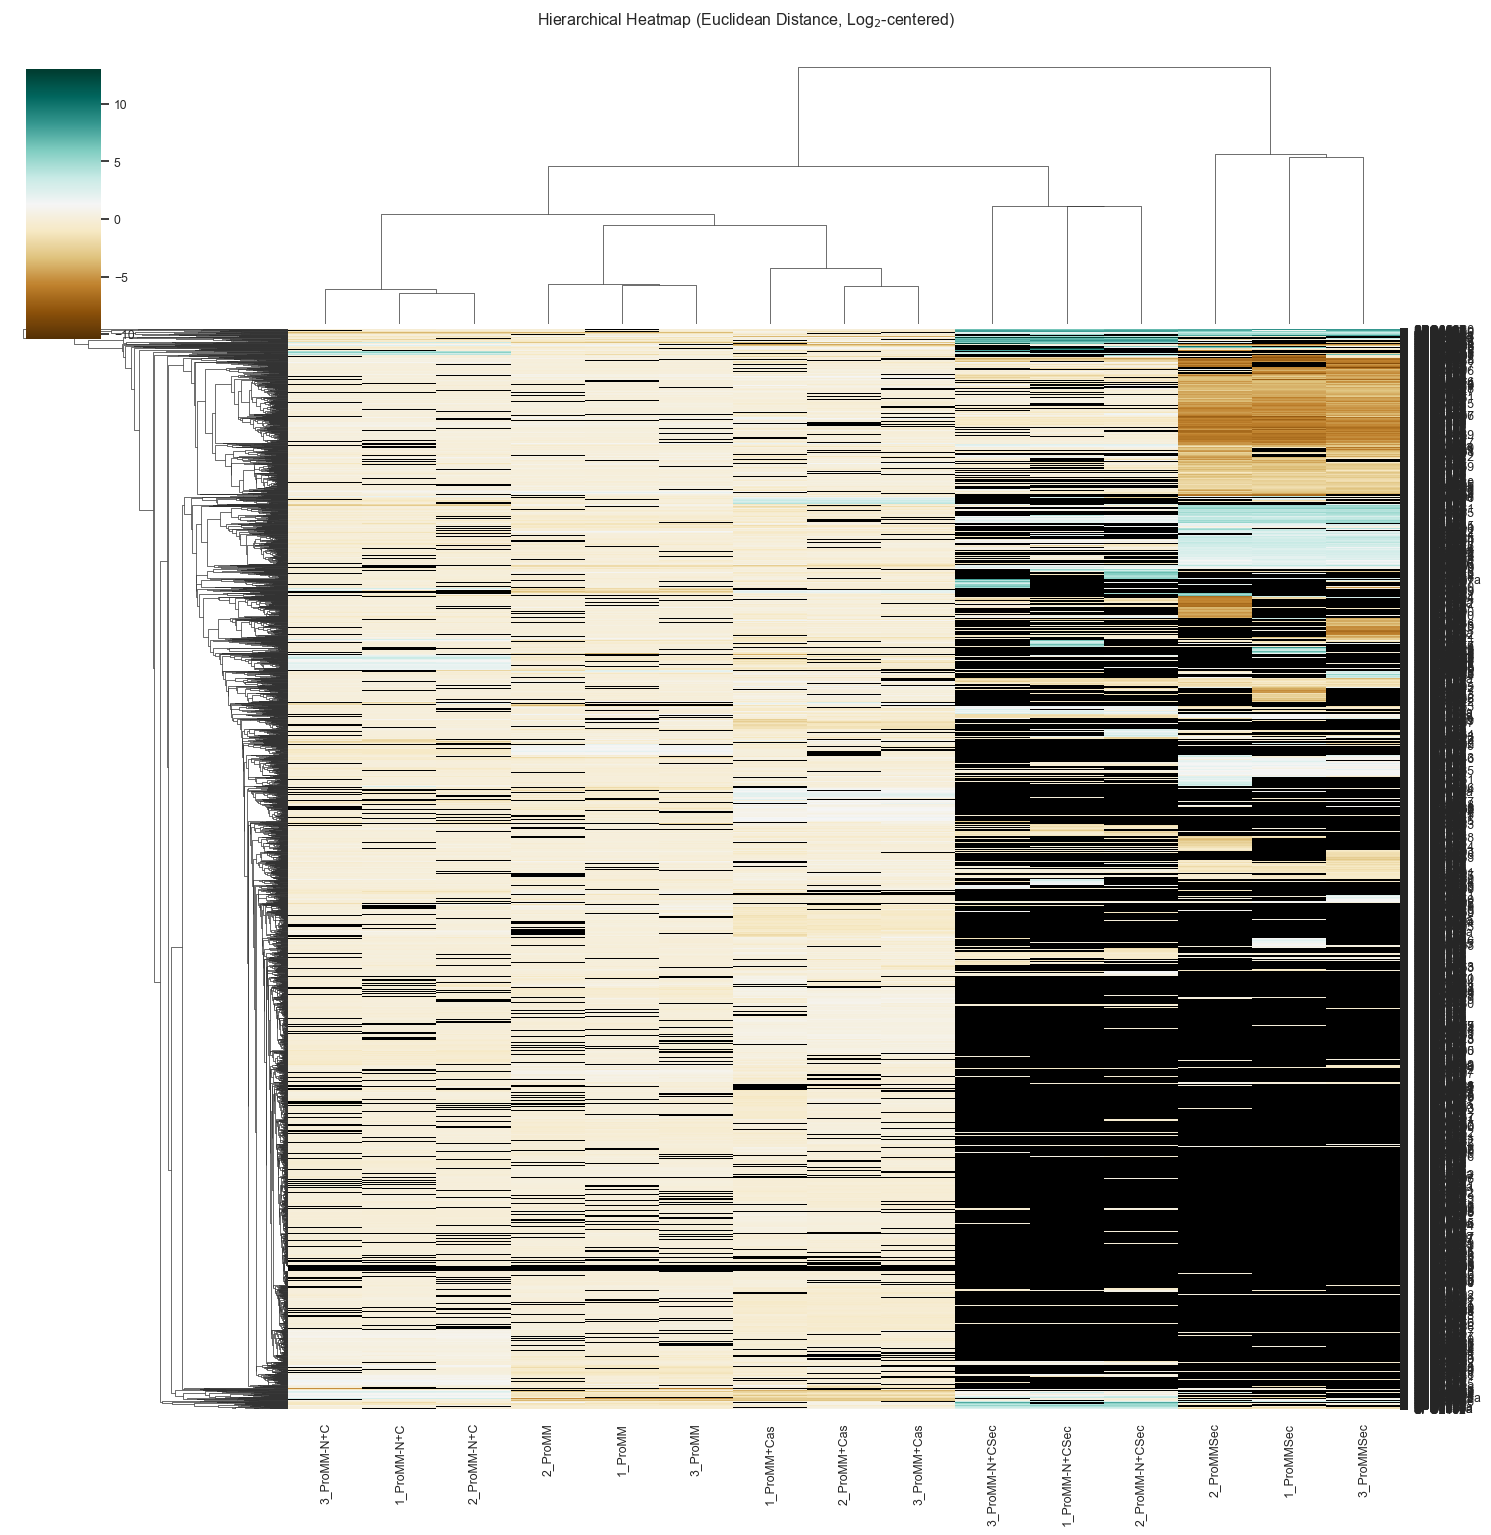

In [16]:
heatmap(merged, suffixes_all, output_filename = 'heatmap_all')

/Users/fadimestemmer/miniconda3/envs/exoprot/lib/python3.9/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/Users/fadimestemmer/miniconda3/envs/exoprot/lib/python3.9/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


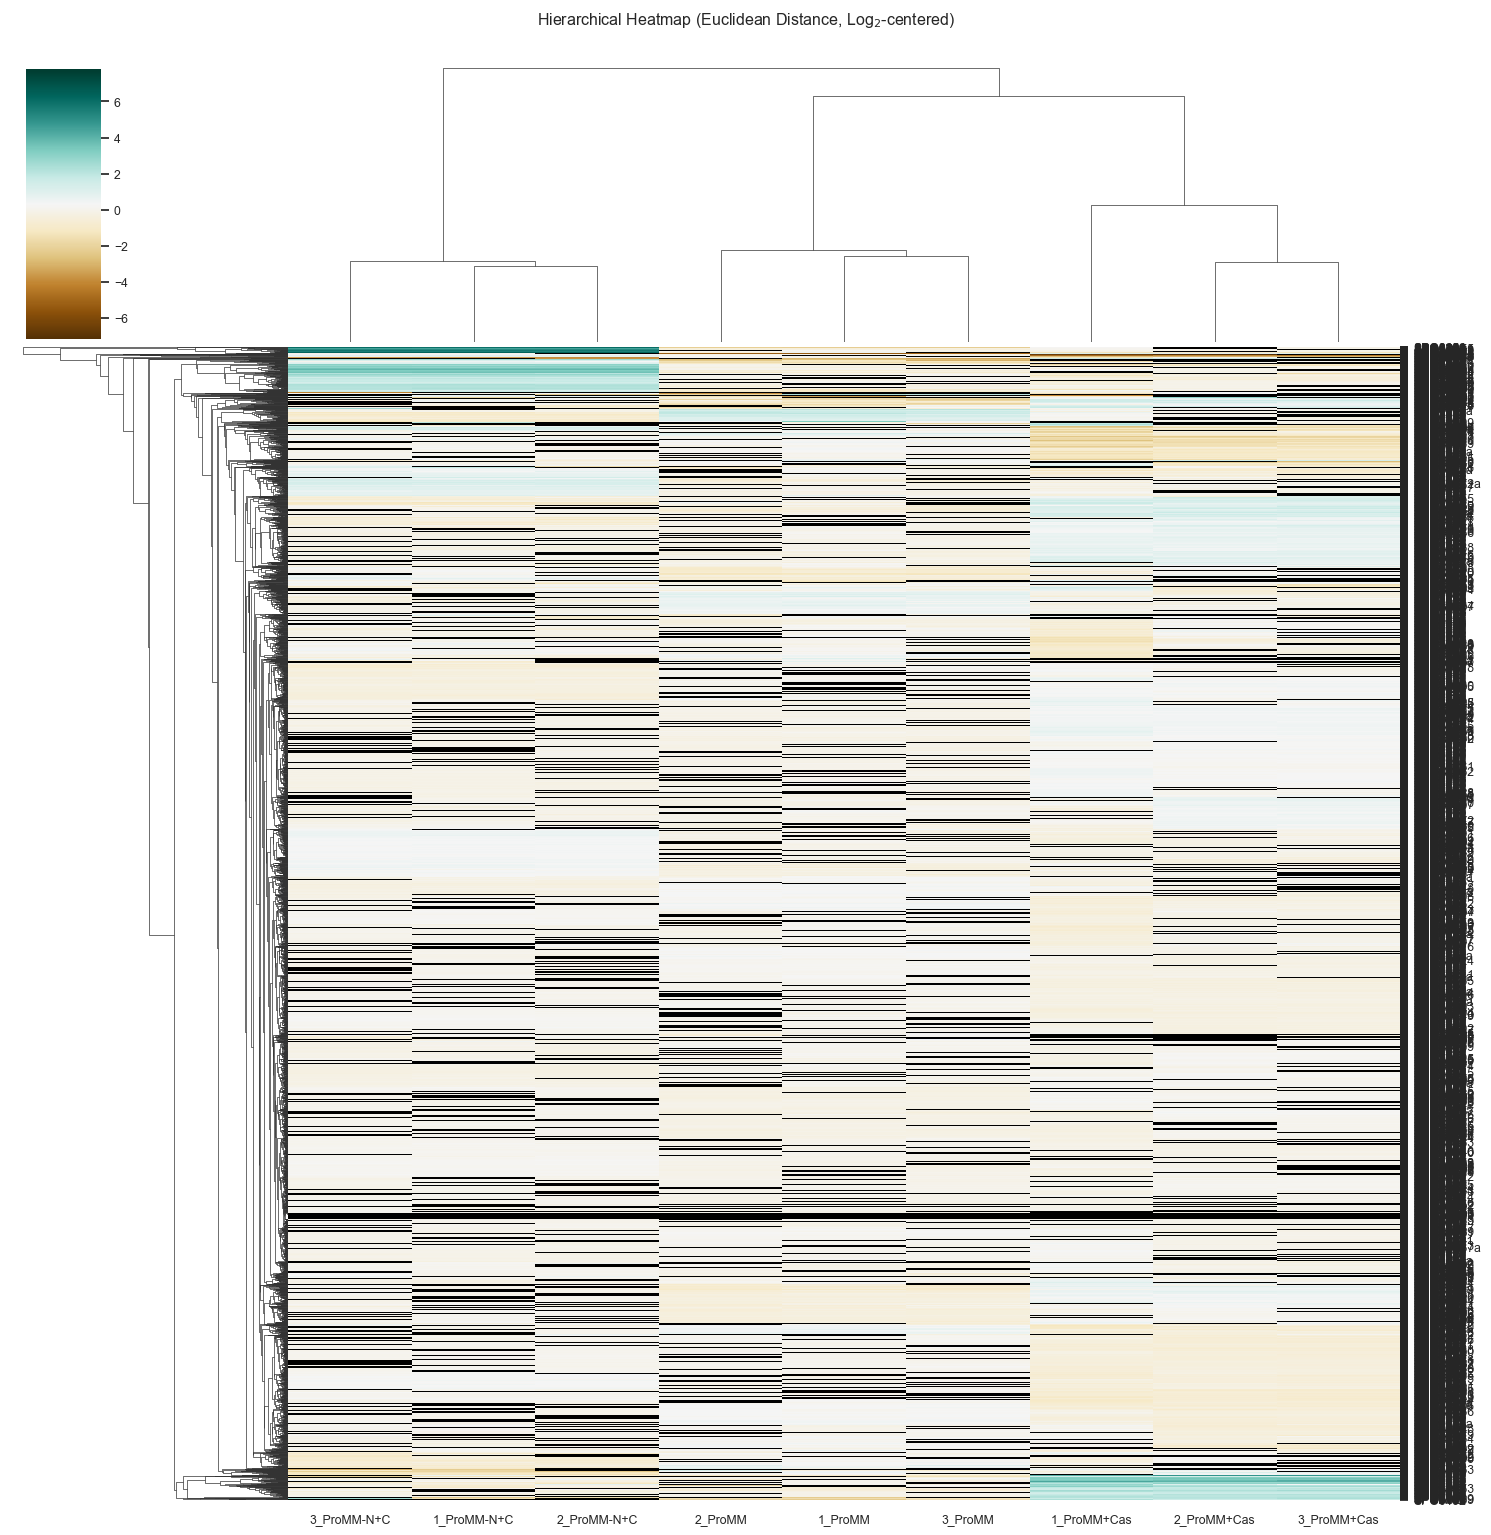

/Users/fadimestemmer/miniconda3/envs/exoprot/lib/python3.9/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/Users/fadimestemmer/miniconda3/envs/exoprot/lib/python3.9/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


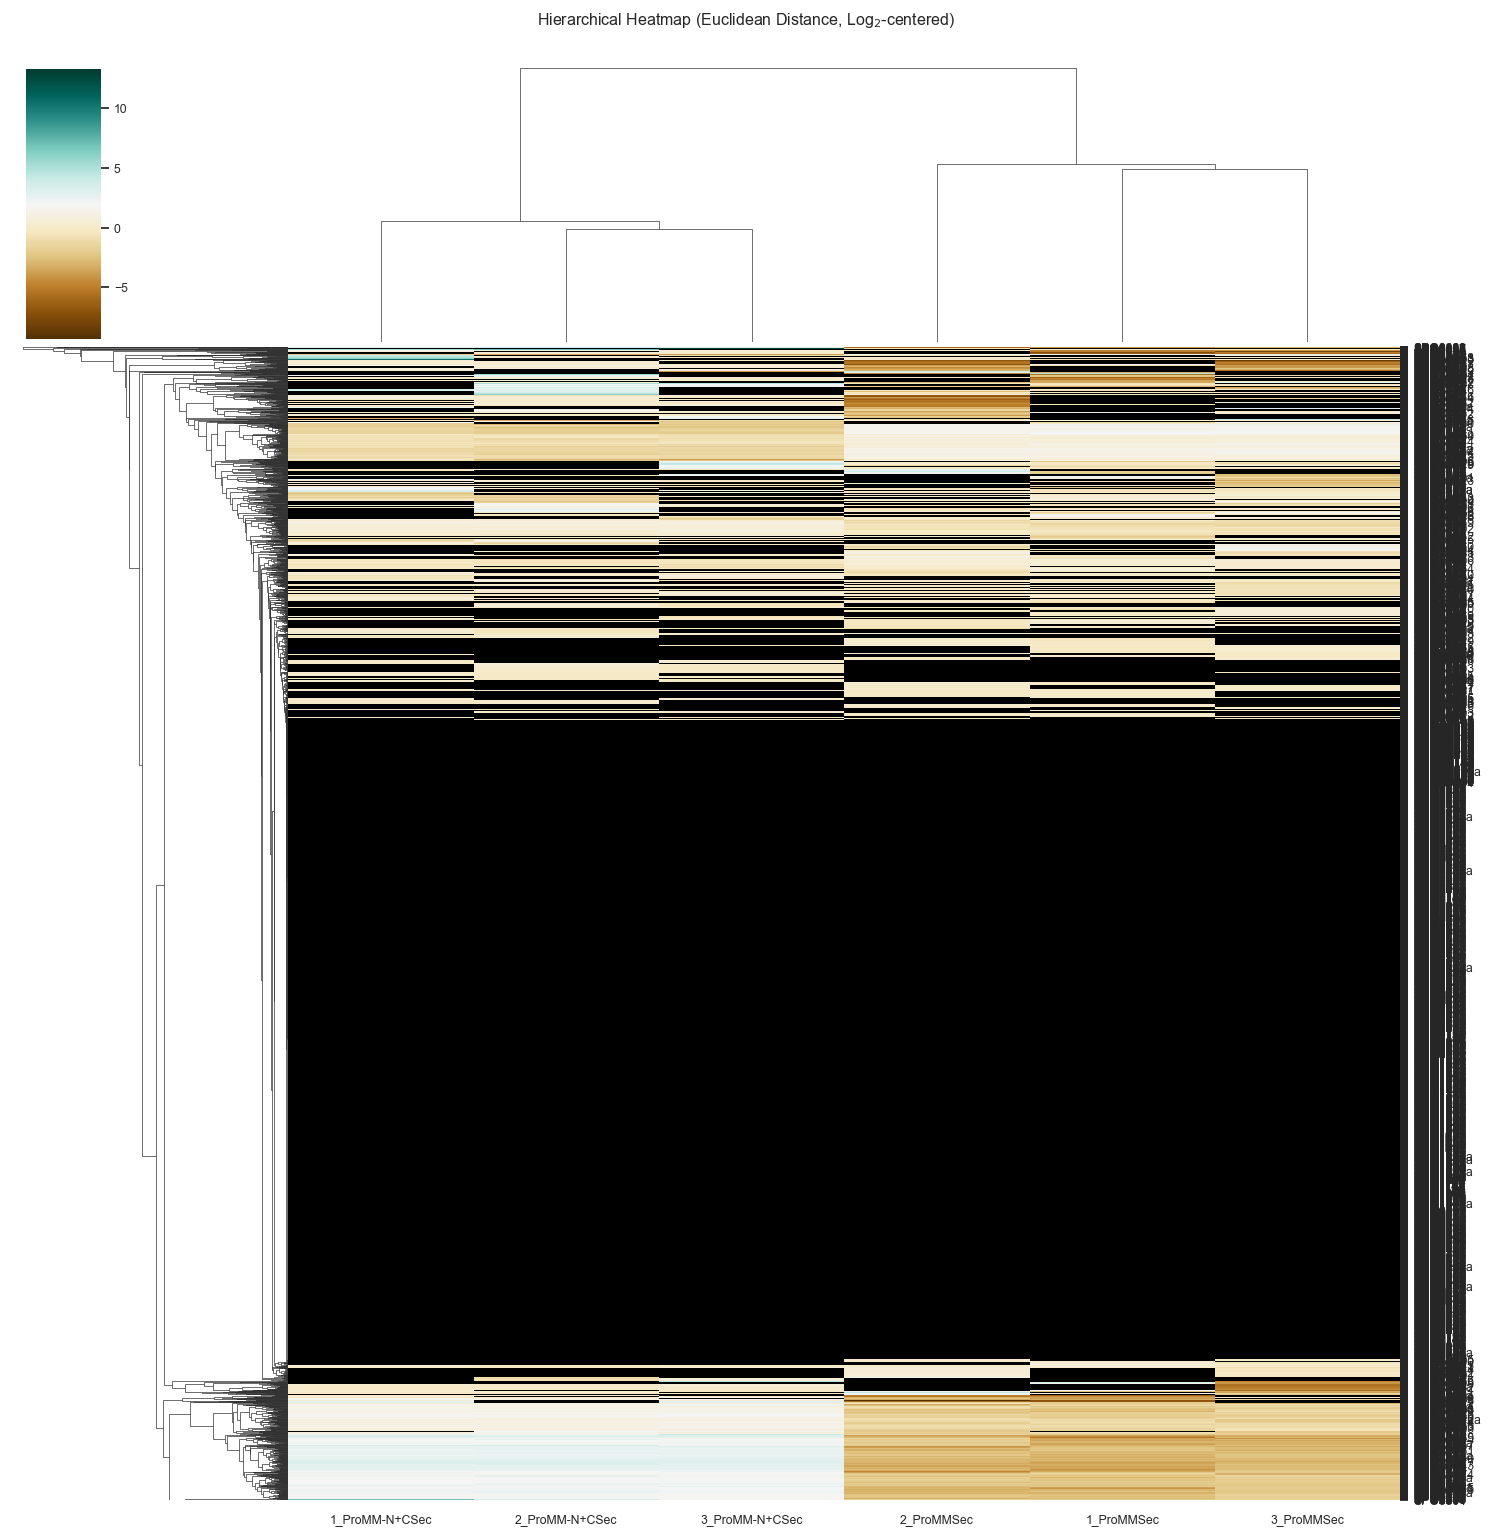

In [23]:
heatmap(merged, suffixes_1, output_filename='heatmap_Intra')
heatmap(merged, suffixes_2, output_filename='heatmap_Sec')

/Users/fadimestemmer/miniconda3/envs/exoprot/lib/python3.9/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/Users/fadimestemmer/miniconda3/envs/exoprot/lib/python3.9/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


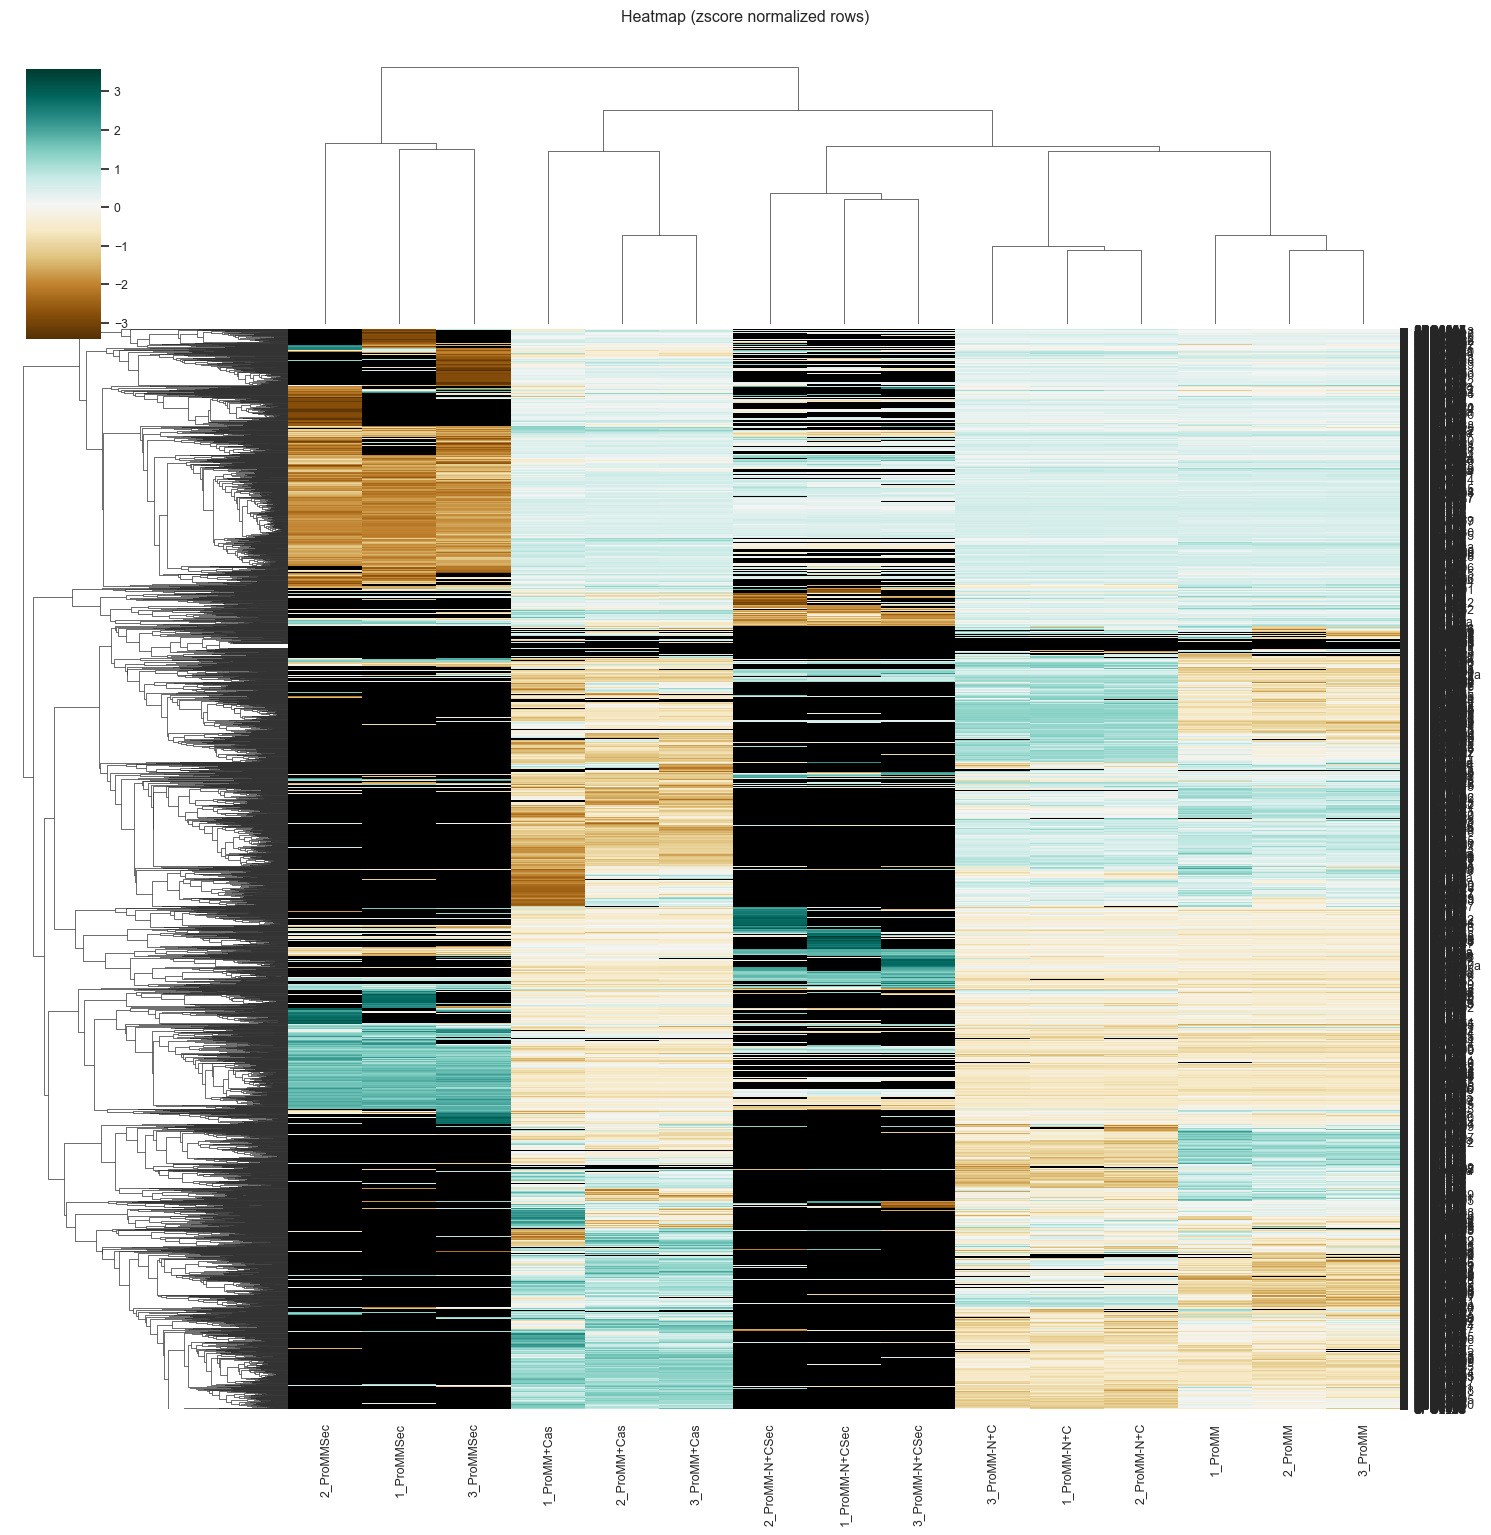

In [37]:
heatmap_normalized(merged, suffixes_all, mode="zscore", output_filename = 'heatmap_all')

/Users/fadimestemmer/miniconda3/envs/exoprot/lib/python3.9/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/Users/fadimestemmer/miniconda3/envs/exoprot/lib/python3.9/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


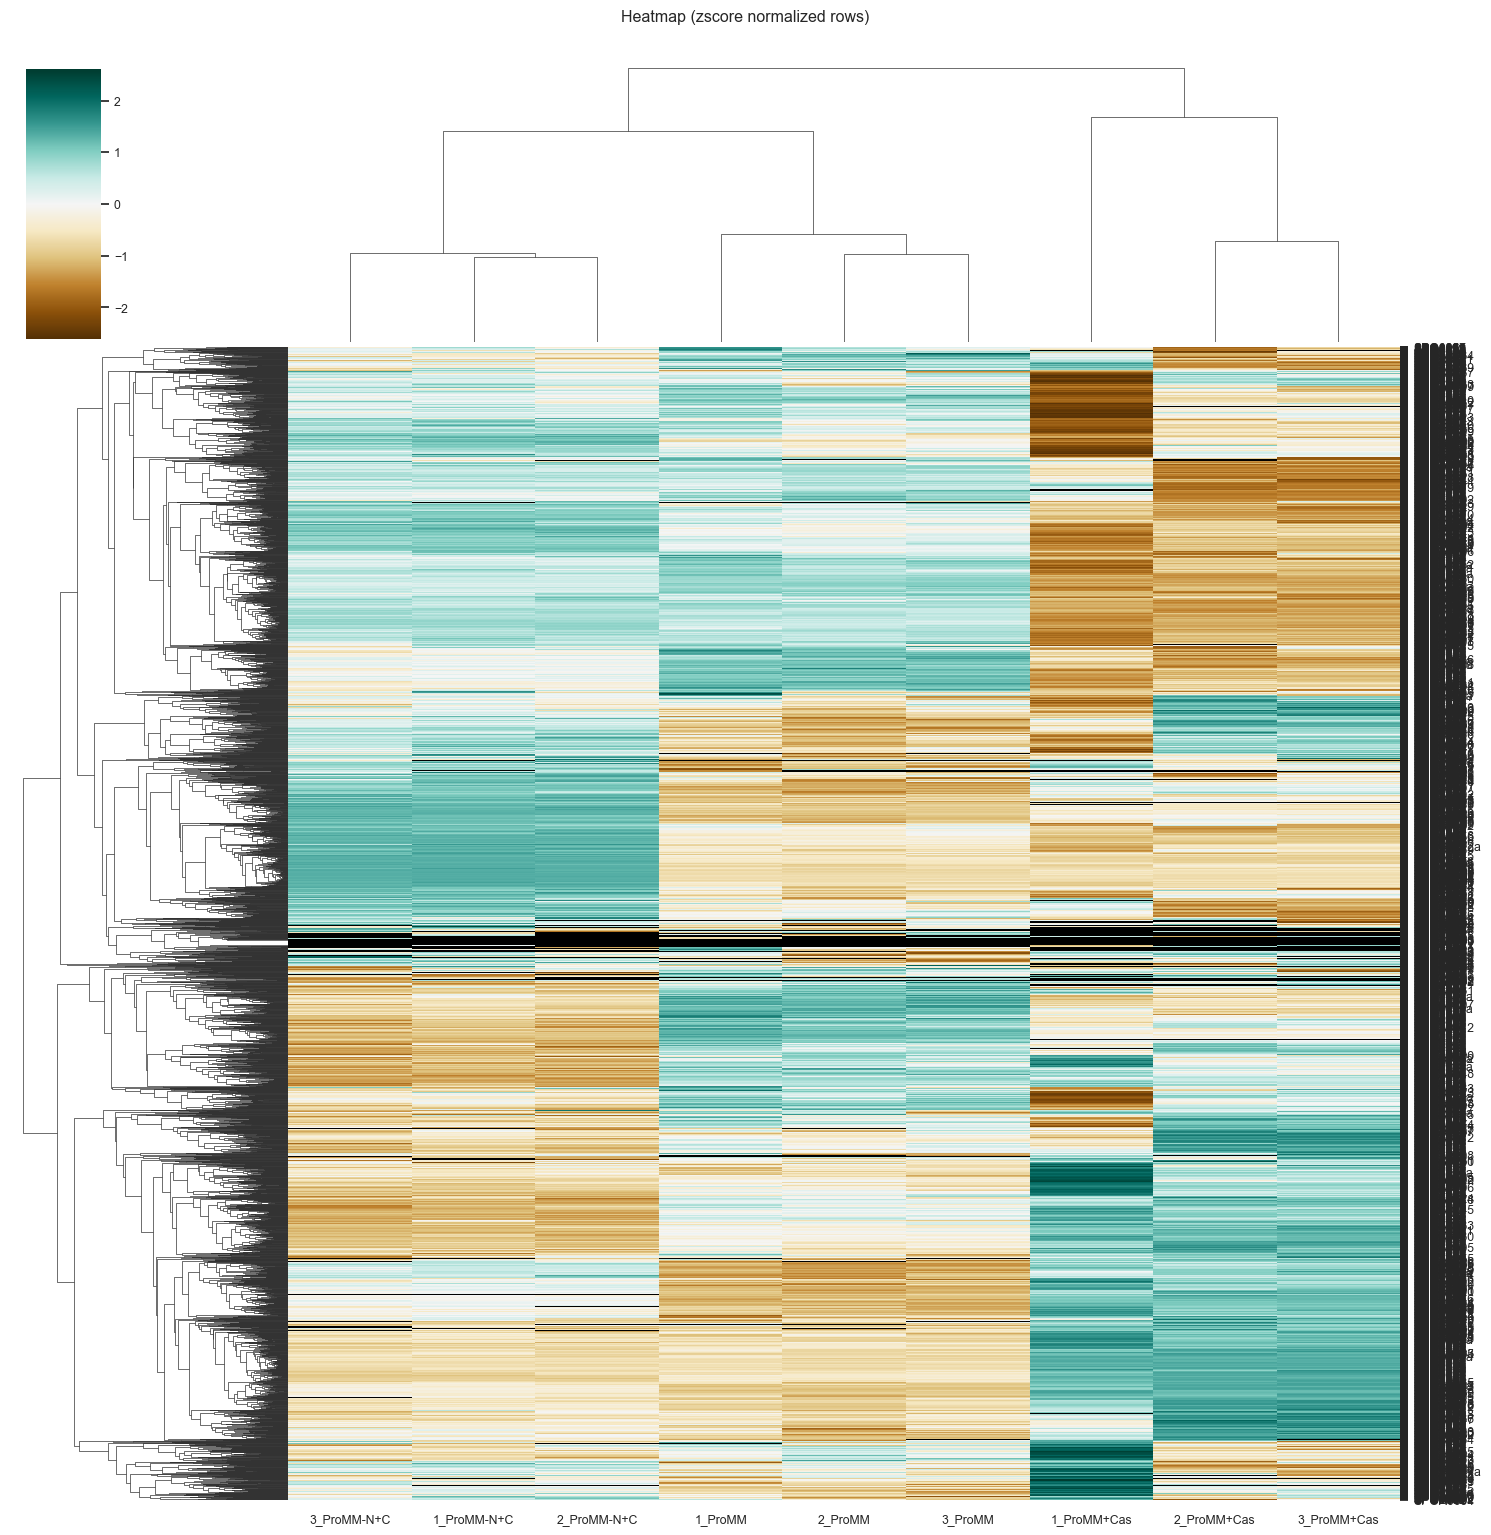

/Users/fadimestemmer/miniconda3/envs/exoprot/lib/python3.9/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/Users/fadimestemmer/miniconda3/envs/exoprot/lib/python3.9/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


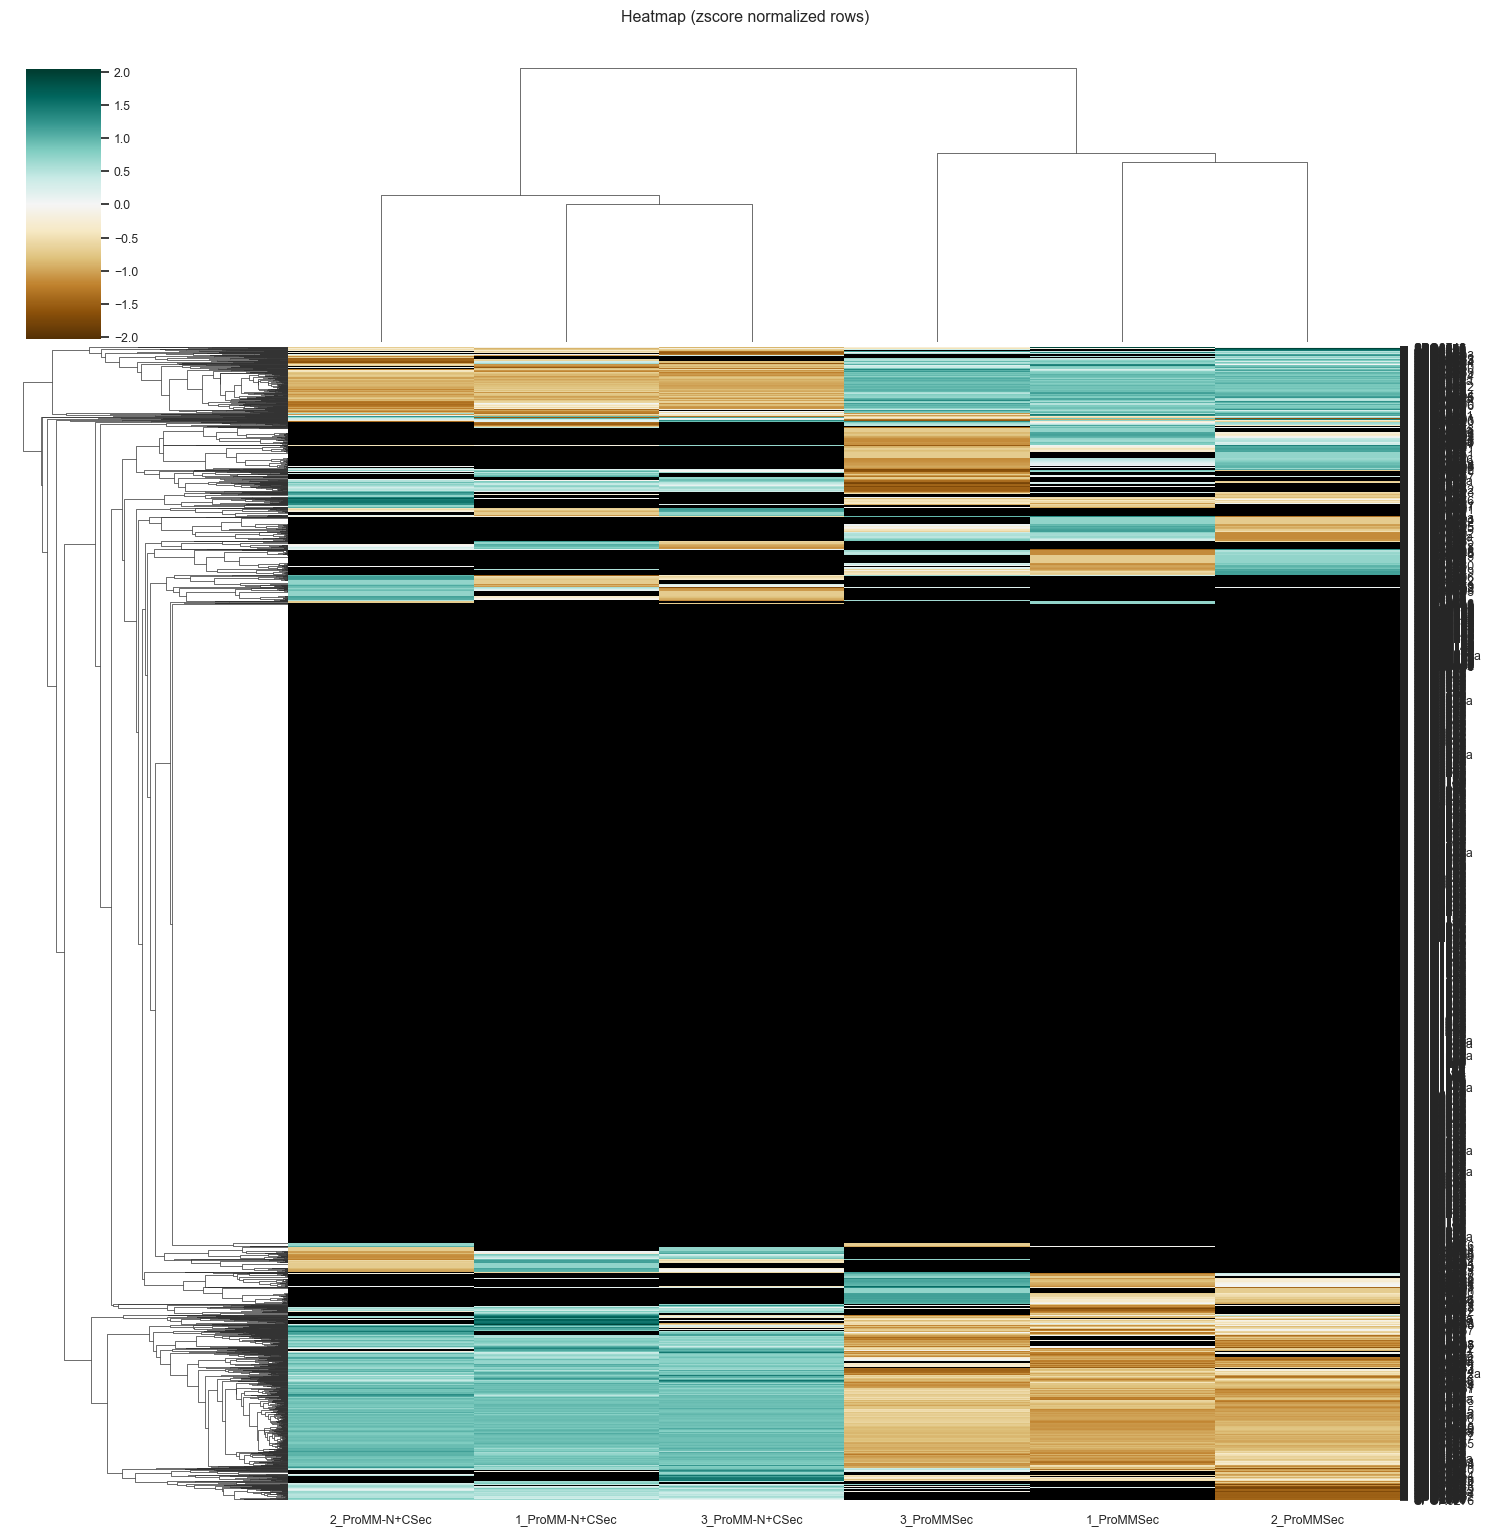

In [38]:
heatmap_normalized(merged, suffixes_1, mode='zscore', output_filename='heatmap_Intra')
heatmap_normalized(merged, suffixes_2, mode='zscore', output_filename='heatmap_Sec')

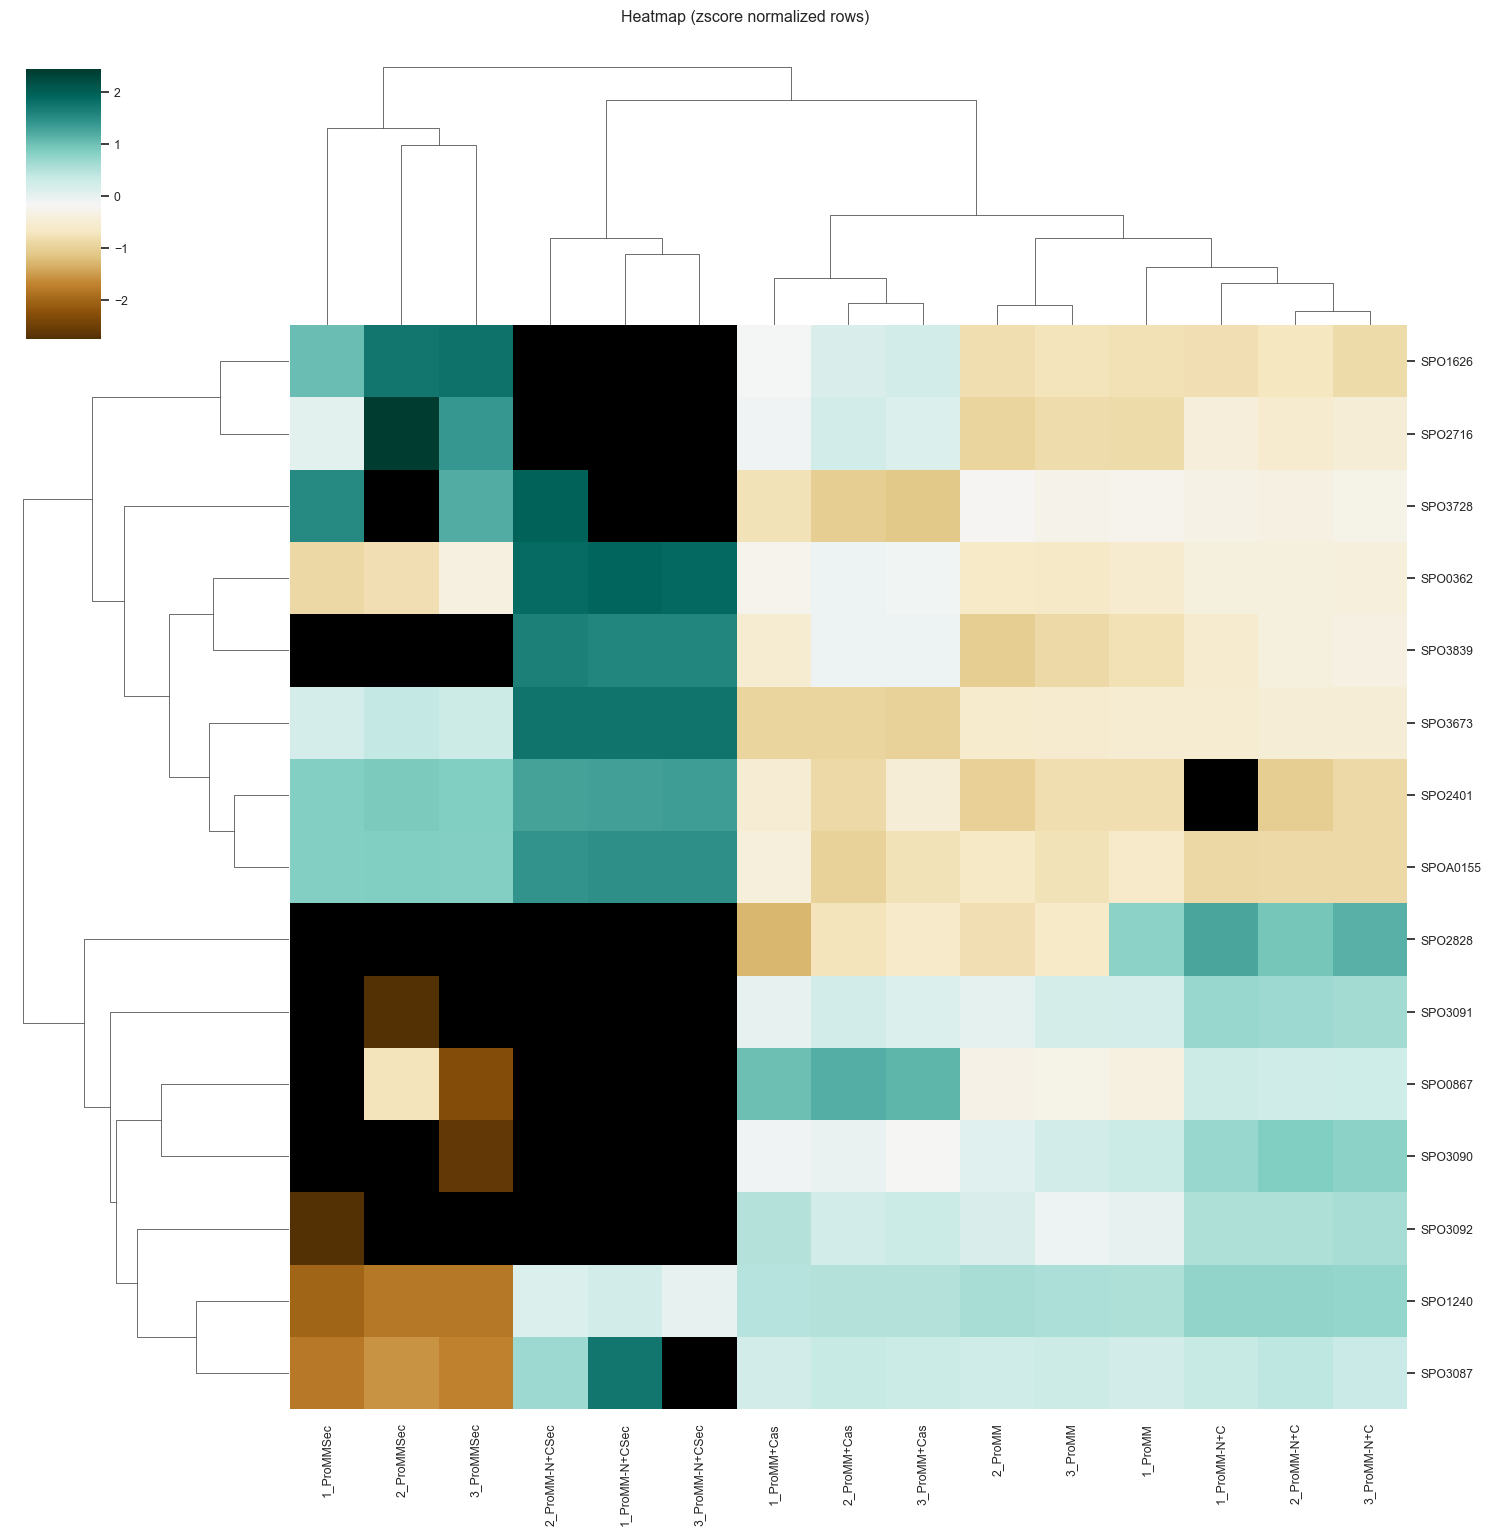

In [9]:
heatmap_normalized(merged, suffixes_all, mode='zscore', keyword='secretion', output_filename='heatmap_secretion')

## Step 5: Bar plot of abundances

In [4]:
# data should still be loaded through the dictionary. If you did not load the data in a previous step but start here, please run this cell. 

'''
Function to load the data from _annotated.txt files as dictionary values and assign to key (= growth medium). 
If successful the function will prompt: "PROTEOME loaded into script!"

USAGE: load_data(folder='FOLDERNAME_CONTAINING_annotated_TXTFILES')
'''
def load_data(folder=''):
    proteome_dic = {}
    
    for file in glob.glob(os.path.join(folder, '*_annotated.txt')):
        parts = os.path.basename(file).replace('.txt', '').strip().split('_')
        
        # Default: just join everything from 2 to 5 like before
        medium_phase = '_'.join(parts[2:3])
        
        data = pd.read_csv(file, delimiter='\t')
        proteome_dic[medium_phase] = data
        print(f"{medium_phase} loaded into script!")
    
    return proteome_dic

proteome_dic=load_data('../data/proteomics/raw/')


'''
Following is a function that merges all dataframes into one for plotting in a heatmap. It is the same as used during NMDS. You do not need
to run this cell if you have already run the NMDS part of this code. 

USAGE: merge_data_dic(DICTIONARY_OF_PROTEOMEDATA, COLUMN_NAMES_OF_TRIPLICATE_MEASUREMENTS)
'''

def merge_data_dic(data_dic, trip_cols=('1', '2', '3')):
    merged = None

    for key, df in data_dic.items():
        df = df.copy()
        # Rename only the triplicate columns that exist in this df
        rename_dict = {c: f"{c}_{key}" for c in trip_cols}
        df = df.rename(columns=rename_dict)

        if merged is None:
            merged = df
        else:
            merged = pd.merge(
                 merged,
                df,
                on=['Accession Number', 'Annotation'],
                how='outer'
            ).sort_values(by='Accession Number')
    return merged

merged = merge_data_dic(proteome_dic)

def extract_suffixes(df, chosen_suffixes=None):
    # Extract all suffixes that appear in df
    all_suffixes = sorted({ col.split('_')[1] for col in df.columns if '_' in col })

    # If user provided a subset, filter to it
    if chosen_suffixes is not None:
        suffixes = [s for s in all_suffixes if s in chosen_suffixes]
    else:
        suffixes = all_suffixes
    return suffixes

ProMM-N+CSec loaded into script!
ProMM loaded into script!
ProMM-N+C loaded into script!
ProMMSec loaded into script!
ProMM+Cas loaded into script!


In [5]:
def plot_spectral_counts(merged_df, spo_accession, ymax = None, expected_conditions=None):
    merged_df = merged_df.copy()
    merged_df.set_index('Accession Number', inplace=True)

    # --- FIX 1: define conditions explicitly ---
    if expected_conditions is None:
        # default: all conditions present anywhere in the dataframe
        expected_conditions = extract_suffixes(merged_df)

    # Check accession
    if spo_accession not in merged_df.index:
        print(f"{spo_accession} not found in file.")
        return

    row = merged_df.loc[spo_accession]

    means = []
    stds = []
    ns = []
    conditions = []
    
    for suffix in expected_conditions:
        trip_cols = [f"{i}_{suffix}" for i in ['1', '2', '3']]
        existing_cols = [c for c in trip_cols if c in row.index]
    
        if len(existing_cols) == 0:
            mean = 0.0
            std = 0.0
            n = 0
        else:
            values = row[existing_cols].astype(float).values
            n = np.sum(~np.isnan(values))
    
            if n == 0:
                mean = 0.0
                std = 0.0
            elif n == 1:
                mean = np.nanmean(values)
                std = 0.0   # cannot compute std with n=1
            else:
                mean = np.nanmean(values)
                std = np.nanstd(values, ddof=1)
    
        means.append(mean)
        stds.append(std)
        ns.append(n)
        conditions.append(suffix)


    # --- Plot ---
    fig, ax = plt.subplots()
    cmap = plt.colormaps['viridis']
    colors = cmap(np.linspace(0, 0.8, len(conditions)))
    
    bars = ax.bar(
        conditions,
        means,
        yerr=stds,
        capsize=5,
        color=colors
    )
    
    # Annotate n
    for bar, std, n in zip(bars, stds, ns):
        height = bar.get_height()
    
        # vertical offset: 2% of y-axis range
        offset = 0.02 * ax.get_ylim()[1]
    
        # place above error bar if present
        y = height + (std if std > 0 else 0) + offset
    
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            y,
            f"n={n}",
            ha='center',
            va='bottom',
            fontsize=20
        )
    if ymax is None:
        ymax = max(m + s for m, s in zip(means, stds))
    else: 
        ymax = ymax
    
    ax.set_ylabel('Normalized Peak Area', fontsize=20)
    ax.set_ylim(bottom=0, top=ymax * 1.15)
    ax.yaxis.get_offset_text().set_fontsize(20)
    ax.set_title(spo_accession, fontsize=20)
    plt.xticks(rotation=45, fontsize=20)
    plt.yticks(fontsize=20)
    plt.tight_layout()
    plt.savefig(f'../figures/proteomics/barplots/bar_{spo_accession}.pdf')
    plt.show()


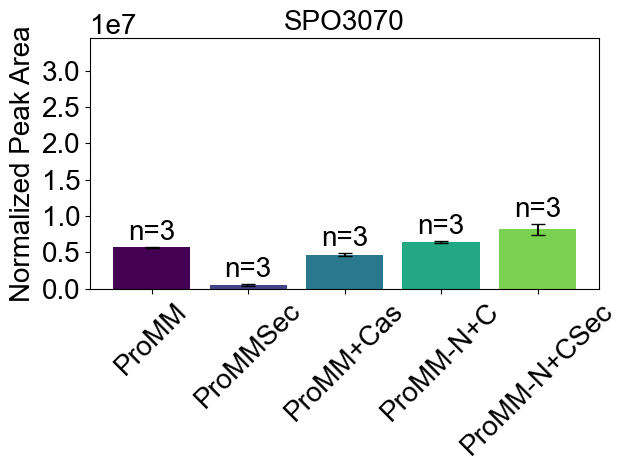

In [33]:
plot_spectral_counts(
    merged,
    spo_accession="SPO3070",
    ymax = 3e7,
    expected_conditions=[
        "ProMM",
        "ProMMSec",
        "ProMM+Cas",
        "ProMM-N+C",
        "ProMM-N+CSec"
    ]
)